In [1]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"



In [2]:
import torch
print("CUDA available:", torch.cuda.is_available())
x = torch.randn(2, 3).cuda()
print("CUDA sanity OK")


CUDA available: True
CUDA sanity OK


In [3]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from scipy.ndimage import gaussian_filter


In [4]:
import os
import random
import numpy as np
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

import timm
from sklearn.model_selection import StratifiedShuffleSplit

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda")
print("Device:", device)


/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

Device: cuda


In [5]:
DATA_ROOT = Path("/kaggle/input/plantvillage-dataset/color")
MODEL_DIR = Path("/kaggle/working/models")
MODEL_DIR.mkdir(exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 5        # keep small for sanity
LR = 3e-4
NUM_WORKERS = 2


In [6]:
image_paths = []
labels = []
class_names = sorted([d.name for d in DATA_ROOT.iterdir() if d.is_dir()])
class_to_idx = {cls: i for i, cls in enumerate(class_names)}

for cls in class_names:
    for img_path in (DATA_ROOT / cls).glob("*"):
        if img_path.suffix.lower() in [".jpg", ".png", ".jpeg"]:
            image_paths.append(img_path)
            labels.append(class_to_idx[cls])

labels = np.array(labels)
NUM_CLASSES = len(class_names)

print("Classes:", NUM_CLASSES)
print("Label range:", labels.min(), labels.max())


Classes: 38
Label range: 0 37


In [7]:
class PlantDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        label = int(self.labels[idx])
        if self.transform:
            img = self.transform(img)
        return img, label


In [8]:
train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225]),
])

val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225]),
])


In [9]:
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, val_idx = next(sss.split(image_paths, labels))

train_ds = PlantDataset(
    [image_paths[i] for i in train_idx],
    labels[train_idx],
    transform=train_tfms
)

val_ds = PlantDataset(
    [image_paths[i] for i in val_idx],
    labels[val_idx],
    transform=val_tfms
)

print("Train:", len(train_ds), "Val:", len(val_ds))




Train: 43444 Val: 10861


In [10]:
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE,
    shuffle=True, num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=NUM_WORKERS,
    pin_memory=True
)


In [11]:
model = timm.create_model(
    "vit_tiny_patch16_224",
    pretrained=True,
    num_classes=NUM_CLASSES
).to(device)

print("Model loaded.")


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

Model loaded.


In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)


In [13]:
best_acc = 0.0

for epoch in range(1, EPOCHS+1):
    model.train()
    train_loss = 0.0

    for imgs, targets in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}"):
        imgs = imgs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Validation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, targets in val_loader:
            imgs = imgs.to(device)
            targets = targets.to(device)
            preds = model(imgs).argmax(dim=1)
            correct += (preds == targets).sum().item()
            total += targets.size(0)

    val_acc = correct / total
    print(f"Epoch {epoch} | Train loss: {train_loss:.4f} | Val acc: {val_acc:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), MODEL_DIR / "best_vit.pth")
        print("Saved best model.")

print("Training complete. Best Val Acc:", best_acc)


Epoch 1/5: 100%|██████████| 1358/1358 [04:06<00:00,  5.52it/s]


Epoch 1 | Train loss: 304.6852 | Val acc: 0.9778
Saved best model.


Epoch 2/5: 100%|██████████| 1358/1358 [03:06<00:00,  7.27it/s]


Epoch 2 | Train loss: 113.4187 | Val acc: 0.9760


Epoch 3/5: 100%|██████████| 1358/1358 [03:06<00:00,  7.28it/s]


Epoch 3 | Train loss: 97.0861 | Val acc: 0.9613


Epoch 4/5: 100%|██████████| 1358/1358 [03:06<00:00,  7.30it/s]


Epoch 4 | Train loss: 87.1338 | Val acc: 0.9736


Epoch 5/5: 100%|██████████| 1358/1358 [03:06<00:00,  7.29it/s]


Epoch 5 | Train loss: 77.3782 | Val acc: 0.9791
Saved best model.
Training complete. Best Val Acc: 0.9790995304299788


In [14]:
# Load best saved model
model.load_state_dict(torch.load(MODEL_DIR / "best_vit.pth", map_location=device))
model.eval()
print("Best model loaded.")


Best model loaded.


In [15]:
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import label_binarize

all_probs = []
all_preds = []
all_targets = []

with torch.no_grad():
    for imgs, targets in tqdm(val_loader, desc="Collecting predictions"):
        imgs = imgs.to(device)
        targets = targets.to(device)

        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1)

        all_probs.append(probs.cpu().numpy())
        all_preds.append(probs.argmax(dim=1).cpu().numpy())
        all_targets.append(targets.cpu().numpy())

all_probs = np.vstack(all_probs)
all_preds = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)

print("Predictions collected.")


Predictions collected.


In [16]:
from sklearn.metrics import roc_curve, auc

# Binarize labels for one-vs-rest ROC
y_true_bin = label_binarize(all_targets, classes=np.arange(NUM_CLASSES))

fpr = {}
tpr = {}
roc_auc = {}

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Micro-average ROC
fpr["micro"], tpr["micro"], _ = roc_curve(
    y_true_bin.ravel(), all_probs.ravel()
)
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

print("Micro-average AUC:", roc_auc["micro"])
print("Per-class AUC (min / max):",
      min(roc_auc[i] for i in range(NUM_CLASSES)),
      max(roc_auc[i] for i in range(NUM_CLASSES)))


Micro-average AUC: 0.9999423668162678
Per-class AUC (min / max): 0.999478388339881 1.0


In [17]:
model.eval()

all_probs = []
all_targets = []

with torch.no_grad():
    for imgs, targets in val_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        probs = F.softmax(outputs, dim=1).cpu().numpy()
        
        all_probs.append(probs)
        all_targets.append(targets.numpy())

all_probs = np.vstack(all_probs)
all_targets = np.concatenate(all_targets)

print("Probs shape:", all_probs.shape)
print("Targets shape:", all_targets.shape)


Probs shape: (10861, 38)
Targets shape: (10861,)


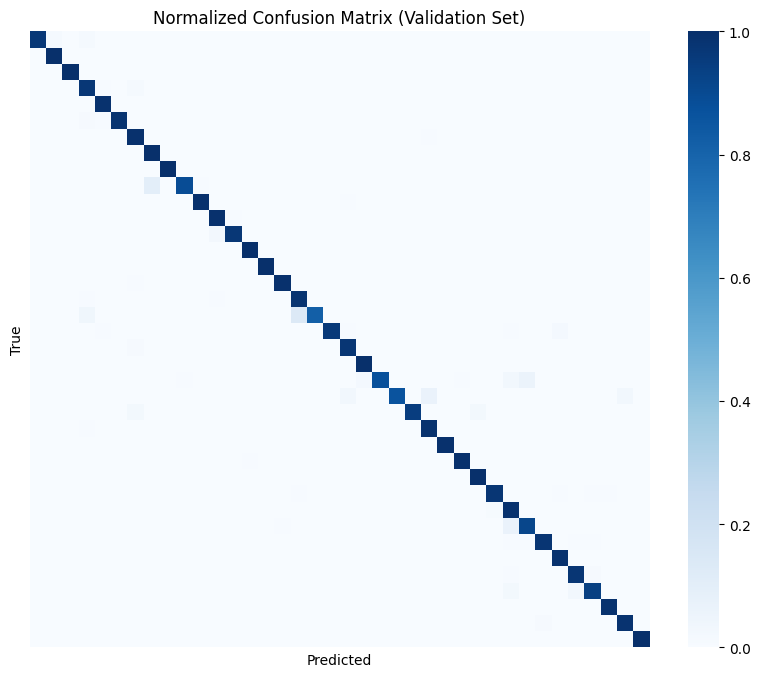

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(all_targets, all_preds)

# Normalize
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    cmap="Blues",
    xticklabels=False,
    yticklabels=False
)
plt.title("Normalized Confusion Matrix (Validation Set)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


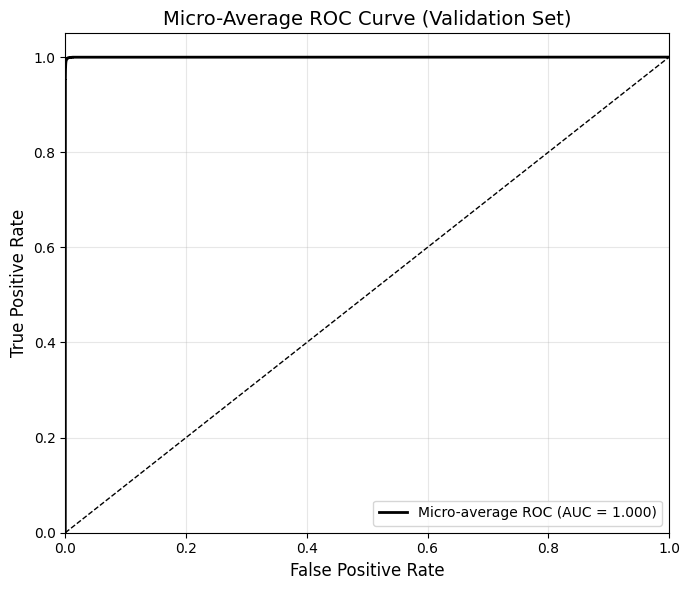

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))
plt.plot(
    fpr["micro"],
    tpr["micro"],
    label=f"Micro-average ROC (AUC = {roc_auc['micro']:.3f})",
    color="black",
    linewidth=2
)

plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("Micro-Average ROC Curve (Validation Set)", fontsize=14)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


/tmp/ipykernel_24/1185364468.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("tab10")


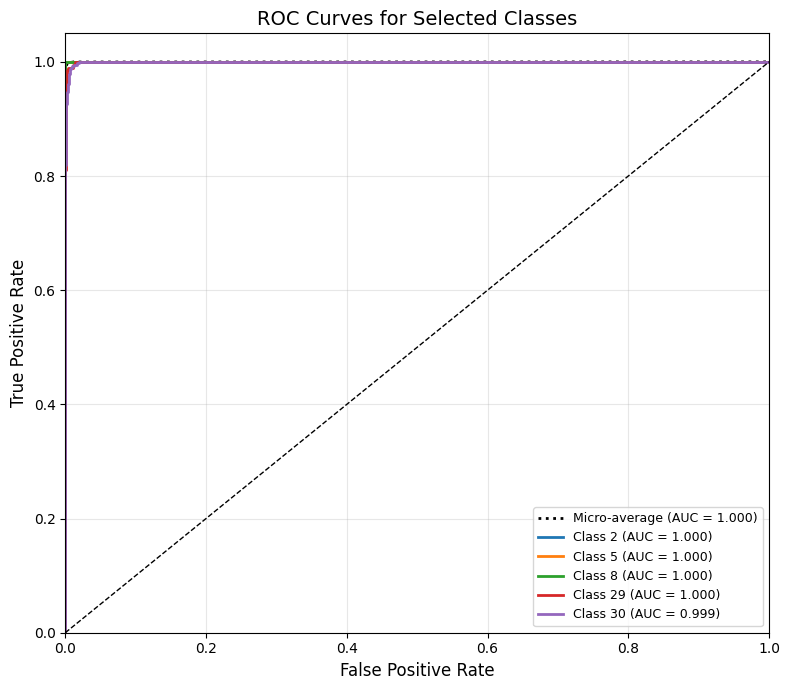

In [20]:
import numpy as np
from matplotlib.cm import get_cmap

# Sort classes by AUC
sorted_classes = sorted(
    range(NUM_CLASSES),
    key=lambda i: roc_auc[i],
    reverse=True
)

top_k = 3
bottom_k = 2
selected_classes = (
    sorted_classes[:top_k] +
    sorted_classes[-bottom_k:]
)

cmap = get_cmap("tab10")

plt.figure(figsize=(8, 7))

# Micro-average first
plt.plot(
    fpr["micro"],
    tpr["micro"],
    color="black",
    linestyle=":",
    linewidth=2,
    label=f"Micro-average (AUC = {roc_auc['micro']:.3f})"
)

# Class-wise ROC
for idx, cls in enumerate(selected_classes):
    plt.plot(
        fpr[cls],
        tpr[cls],
        linewidth=2,
        color=cmap(idx),
        label=f"Class {cls} (AUC = {roc_auc[cls]:.3f})"
    )

plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curves for Selected Classes", fontsize=14)
plt.legend(fontsize=9)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


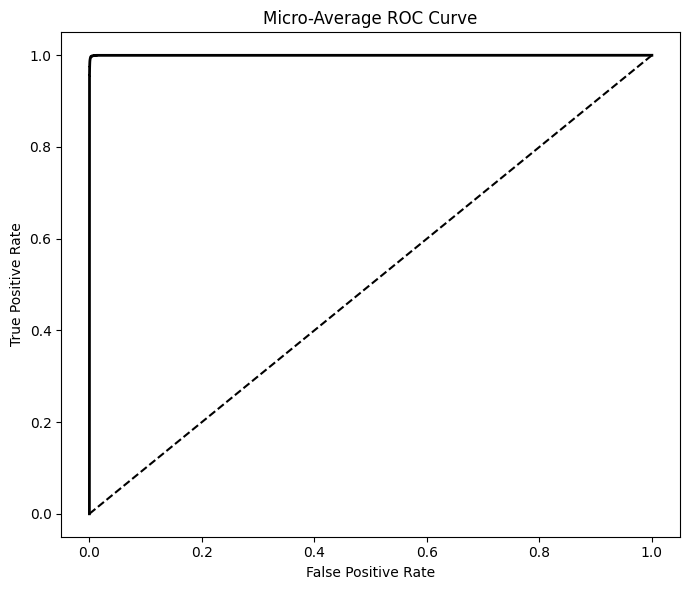

In [21]:
plt.figure(figsize=(7, 6))
plt.plot(fpr["micro"], tpr["micro"], color="black", linewidth=2)
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Micro-Average ROC Curve")
plt.tight_layout()
plt.savefig("roc_micro_average.png", dpi=300)
plt.show()


In [22]:
NUM_CLASSES = all_probs.shape[1]
y_true_bin = label_binarize(all_targets, classes=np.arange(NUM_CLASSES))

fpr = {}
tpr = {}
roc_auc = {}

for i in range(NUM_CLASSES):
    if y_true_bin[:, i].sum() == 0:
        roc_auc[i] = np.nan
        continue
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Macro average
valid_aucs = [v for v in roc_auc.values() if not np.isnan(v)]
macro_auc = np.mean(valid_aucs)

print("Macro AUC:", round(macro_auc, 4))


Macro AUC: 0.9999


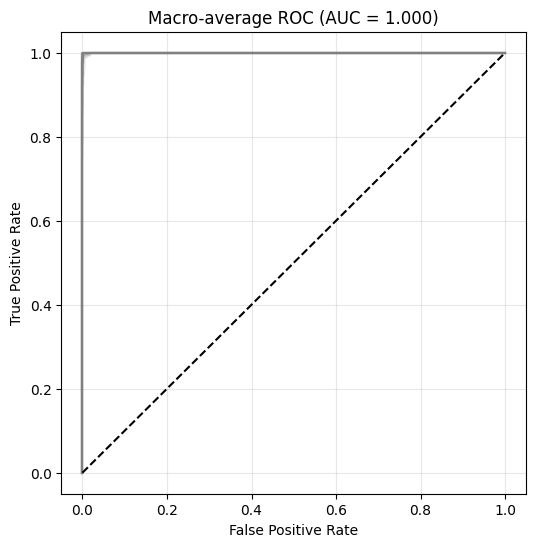

In [23]:
plt.figure(figsize=(6,6))

for i in range(NUM_CLASSES):
    if i in fpr:
        plt.plot(fpr[i], tpr[i], color="gray", alpha=0.1)

plt.plot([0,1], [0,1], 'k--')
plt.title(f"Macro-average ROC (AUC = {macro_auc:.3f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(alpha=0.3)
plt.show()


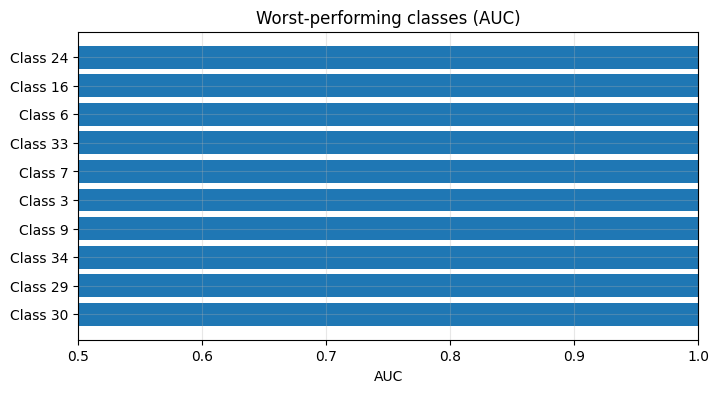

In [24]:
# Sort classes by AUC
sorted_items = sorted(roc_auc.items(), key=lambda x: x[1])
worst_k = 10

classes = [f"Class {i}" for i,_ in sorted_items[:worst_k]]
values = [v for _,v in sorted_items[:worst_k]]

plt.figure(figsize=(8,4))
plt.barh(classes, values)
plt.xlabel("AUC")
plt.title("Worst-performing classes (AUC)")
plt.xlim(0.5, 1.0)
plt.grid(alpha=0.3)
plt.show()



In [25]:
def reliability_diagram(probs, targets, n_bins=15):
    confidences = probs.max(axis=1)
    predictions = probs.argmax(axis=1)
    accuracies = predictions == targets

    bins = np.linspace(0, 1, n_bins+1)
    bin_ids = np.digitize(confidences, bins) - 1

    bin_acc = []
    bin_conf = []
    ece = 0.0

    for b in range(n_bins):
        mask = bin_ids == b
        if mask.sum() == 0:
            continue
        acc = accuracies[mask].mean()
        conf = confidences[mask].mean()
        bin_acc.append(acc)
        bin_conf.append(conf)
        ece += np.abs(acc - conf) * mask.mean()

    return bin_conf, bin_acc, ece


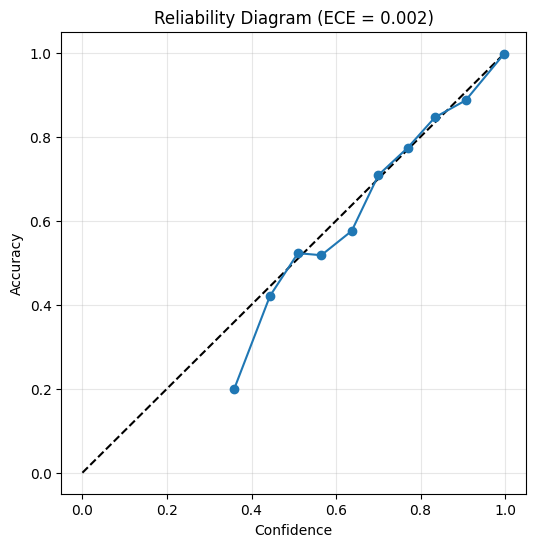

In [26]:
bin_conf, bin_acc, ece = reliability_diagram(all_probs, all_targets)

plt.figure(figsize=(6,6))
plt.plot([0,1],[0,1],'k--')
plt.plot(bin_conf, bin_acc, marker='o')
plt.xlabel("Confidence")
plt.ylabel("Accuracy")
plt.title(f"Reliability Diagram (ECE = {ece:.3f})")
plt.grid(alpha=0.3)
plt.show()


In [27]:
def evaluate_with_noise(sigma):
    model.eval()
    all_probs = []

    with torch.no_grad():
        for imgs, _ in val_loader:
            imgs = imgs.to(device)

            # add Gaussian noise in torch (keeps float32)
            noise = torch.randn_like(imgs) * sigma
            noisy_imgs = torch.clamp(imgs + noise, 0, 1)

            outputs = model(noisy_imgs)
            probs = F.softmax(outputs, dim=1)
            all_probs.append(probs.cpu().numpy())

    all_probs = np.vstack(all_probs)

    fpr_n, tpr_n, _ = roc_curve(
        y_true_bin.ravel(),
        all_probs.ravel()
    )
    return auc(fpr_n, tpr_n)


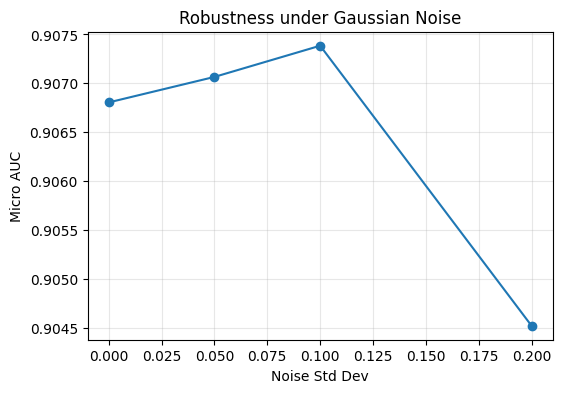

In [28]:
sigmas = [0.0, 0.05, 0.1, 0.2]
aucs_noise = [evaluate_with_noise(s) for s in sigmas]

plt.figure(figsize=(6,4))
plt.plot(sigmas, aucs_noise, marker='o')
plt.xlabel("Noise Std Dev")
plt.ylabel("Micro AUC")
plt.title("Robustness under Gaussian Noise")
plt.grid(alpha=0.3)
plt.show()


**Explainable AI**

**Grad cam**

In [29]:
import cv2


In [30]:
import torchvision.models as models
import torch.nn as nn

cnn_explainer = models.resnet18(pretrained=True)
cnn_explainer.fc = nn.Linear(cnn_explainer.fc.in_features, NUM_CLASSES)
cnn_explainer = cnn_explainer.to(device)

optimizer_cnn = torch.optim.Adam(cnn_explainer.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 185MB/s]


In [31]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, x, class_idx):
        self.model.zero_grad()
        out = self.model(x)
        out[:, class_idx].backward()

        weights = self.gradients.mean(dim=(2,3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1)
        cam = torch.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        return cam.detach().cpu().numpy()


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1864: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


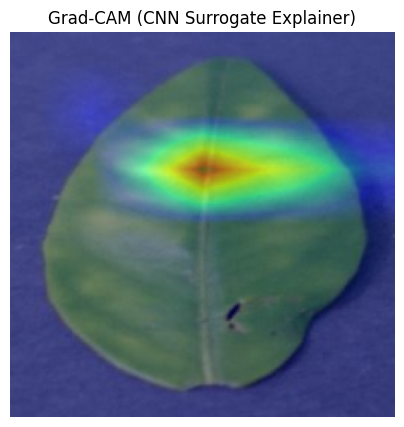

In [32]:
imgs, labels = next(iter(val_loader))
img = imgs[0:1].to(device)
label = labels[0].item()

target_layer = cnn_explainer.layer4[-1].conv2
cam = GradCAM(cnn_explainer, target_layer).generate(img, label)

img_np = img[0].permute(1,2,0).cpu().numpy()
img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

cam_resized = cv2.resize(cam[0], (img_np.shape[1], img_np.shape[0]))

plt.figure(figsize=(5,5))
plt.imshow(img_np)
plt.imshow(cam_resized, cmap='jet', alpha=0.45)
plt.title("Grad-CAM (CNN Surrogate Explainer)")
plt.axis("off")
plt.show()


**LIME**

In [33]:
from lime import lime_image
from skimage.segmentation import mark_boundaries

explainer = lime_image.LimeImageExplainer()


  0%|          | 0/1000 [00:00<?, ?it/s]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8267832..1.8158263].


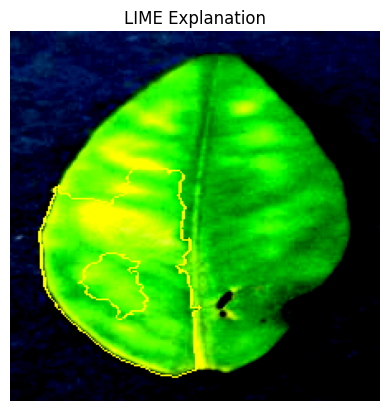

In [34]:
def predict_fn(images):
    images = torch.tensor(images).permute(0,3,1,2).float().to(device)
    with torch.no_grad():
        outputs = model(images)
        return F.softmax(outputs, dim=1).cpu().numpy()

img_np = img[0].permute(1,2,0).cpu().numpy()

explanation = explainer.explain_instance(
    img_np,
    predict_fn,
    top_labels=1,
    hide_color=0,
    num_samples=1000
)

temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=5,
    hide_rest=False
)

plt.imshow(mark_boundaries(temp, mask))
plt.title("LIME Explanation")
plt.axis("off")
plt.show()


**Responsible AI**

In [35]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import accuracy_score



In [36]:
def collect_probs(model, loader, device):
    model.eval()
    all_probs, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Collecting probabilities"):
            imgs = imgs.to(device)
            outputs = model(imgs)
            probs = F.softmax(outputs, dim=1)

            all_probs.append(probs.cpu())
            all_labels.append(labels)

    return torch.cat(all_probs), torch.cat(all_labels)


In [37]:
probs, labels = collect_probs(model, val_loader, device)
preds = probs.argmax(dim=1)


In [38]:
def expected_calibration_error(probs, labels, n_bins=15):
    confidences, predictions = probs.max(dim=1)
    accuracies = predictions.eq(labels)

    ece = torch.zeros(1)
    bin_boundaries = torch.linspace(0, 1, n_bins + 1)

    for i in range(n_bins):
        mask = (confidences > bin_boundaries[i]) & (confidences <= bin_boundaries[i+1])
        if mask.sum() > 0:
            acc = accuracies[mask].float().mean()
            conf = confidences[mask].mean()
            ece += (mask.float().mean()) * torch.abs(acc - conf)

    return ece.item()


In [39]:
ece = expected_calibration_error(probs, labels)
print(f"Expected Calibration Error (ECE): {ece:.4f}")


Expected Calibration Error (ECE): 0.0019


In [40]:
def plot_reliability_diagram(probs, labels, n_bins=15):
    confidences, predictions = probs.max(dim=1)
    accuracies = predictions.eq(labels)

    bin_boundaries = torch.linspace(0, 1, n_bins + 1)
    bin_accs, bin_confs = [], []

    for i in range(n_bins):
        mask = (confidences > bin_boundaries[i]) & (confidences <= bin_boundaries[i+1])
        if mask.sum() > 0:
            bin_accs.append(accuracies[mask].float().mean().item())
            bin_confs.append(confidences[mask].mean().item())
        else:
            bin_accs.append(0)
            bin_confs.append(0)

    plt.figure(figsize=(6,6))
    plt.plot([0,1], [0,1], linestyle='--', color='gray')
    plt.bar(bin_confs, bin_accs, width=0.04, edgecolor='black')
    plt.xlabel("Confidence score")
    plt.ylabel("Rolling Accuracy")
    plt.title("Reliability Diagram")
    plt.show()


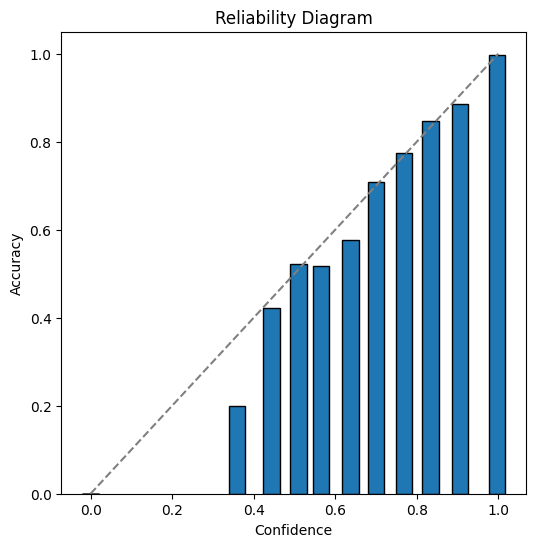

In [41]:
plot_reliability_diagram(probs, labels)


In [42]:
def evaluate_noise_robustness(model, loader, sigmas):
    results = []

    model.eval()
    for sigma in sigmas:
        correct, total = 0, 0

        with torch.no_grad():
            for imgs, labels in loader:
                imgs, labels = imgs.to(device), labels.to(device)
                noise = torch.randn_like(imgs) * sigma
                noisy_imgs = imgs + noise

                outputs = model(noisy_imgs)
                preds = outputs.argmax(dim=1)

                correct += (preds == labels).sum().item()
                total += labels.size(0)

        acc = correct / total
        results.append(acc)

    return results


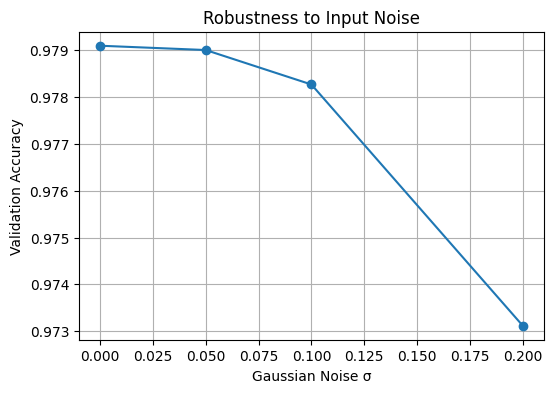

In [43]:
sigmas = [0.0, 0.05, 0.1, 0.2]
noise_accs = evaluate_noise_robustness(model, val_loader, sigmas)

plt.figure(figsize=(6,4))
plt.plot(sigmas, noise_accs, marker='o')
plt.xlabel("Gaussian Noise ")
plt.ylabel("Validation RAccuracy")
plt.title("Robustness to Input Noise")
plt.grid(True)
plt.show()


In [44]:
def analyze_failures(probs, labels, threshold=0.6):
    confidences, preds = probs.max(dim=1)
    failures = (preds != labels) & (confidences < threshold)

    print(f"confidence failures: {failures.sum().item()}")
    print(f"Failure progression rate: {failures.float().mean().item():.4f}")


In [45]:
analyze_failures(probs, labels)


Low-confidence failures: 67
Failure rate: 0.0062
